# FINANCIAL INTERMEDIATION

In [1]:
# PACKAGES AND PATHS
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj
from sequence_jacobian import simple, solved, combine, create_model
from sequence_jacobian import grids, hetblocks

from pathlib import Path
import numpy as np
import scipy.linalg
import os

from pathlib import Path
import numpy as np
import scipy.linalg
from sequence_jacobian import grids

# 1. Robust Path Definition
try:
    # Works if running as a .py script
    BASE_DIR_D = Path(__file__).resolve().parent
except NameError:
    # Works if running in a Jupyter Notebook
    BASE_DIR_D = Path.cwd()

# REMOVE .parent here. 
# Your image shows 'Discretisation' is in the same folder as the notebook.
DATA_DIR_D = BASE_DIR_D / "Discretisation" / "Outputs"

In [2]:
# CALIBRATION
calibration_start = {

    #==> Household parameters
    'frisch_D': 1.0,    'frisch_F': 1.0,    # Frisch elasticity of labour supply
    'eis_D': 0.5,       'eis_F': 0.5,       # Intertemporal elasticity of substitution
    'habit_D': 0.00,    'habit_F': 0.00,    # Habit formation
    'C_lag_D': 0.0,     'C_lag_F': 0.0,     # Previous consumption

    #==> Deposit rate
    'rdep_D': 0.0065,   'rdep_F': 0.0065,

    #==> Bond rate (= rdep at SS since def_rate=0)
    'rb_D': 0.0065,     'rb_F': 0.0065,

    #==> Government bonds
    'B_supply_D': 0.6 * 4,  'B_supply_F': 0.6 * 4,

    #==> Transfer rule parameters
    'tau_D': 0.181,         'tau_F': 0.181,
    'lamb_D': 0.85,         'lamb_F': 0.85,
    'lamb_ss_D': 0.85,      'lamb_ss_F': 0.85,
    'phi_lamb_D': 0.1,      'phi_lamb_F': 0.1,

    #==> Default parameters
    'shock_def_D': 0.0,     'shock_def_F': 0.0,
    'def_rate_D': 0.0,      'def_rate_F': 0.0,
    'def_curvature_D': 0.5, 'def_curvature_F': 0.5,
    'recovery_rate_D': 0.40,'recovery_rate_F': 0.40,

    #==> Aggregate targets
    'Y_D': 1.00,  'Y_F': 1.00,
    'N_D': 1.00,  'N_F': 1.00,
    'w_D': 0.65,  'w_F': 0.65,

    #==> Financial intermediary
    'f_D': 0.06,            'f_F': 0.06,
    'lambda_gk_D': 0.116,   'lambda_gk_F': 0.116,
    'ksi_D': 0.5,           'ksi_F': 0.5,           # Capital adjustment cost
    'n_inter_D': 0.75 * 4,  'n_inter_F': 0.75 * 4,  # Net worth
    'theta_D': 4,           'theta_F': 4,            # Capital leverage

    #==> Production
    'alpha_D': 0.35,   'alpha_F': 0.35,   # Capital share
    'delta_D': 0.0125, 'delta_F': 0.0125, # Depreciation rate (quarterly)

    #==> Deposit grid
    'nZ_D': 19,       'nZ_F': 21,        # Number of income states
    'nDep_D': 500,    'nDep_F': 500,     # Number of deposit grid points
    'Depmax_D': 150,  'Depmax_F': 150,   # Maximum deposits

    #==> Not used unless nZ != 19
    'rho_z_D': 0.9,   'rho_z_F': 0.97,
    'sigma_z_D': 0.5, 'sigma_z_F': 0.8,

    #==> Tobin's q
    'Q_D': 1.0,       'Q_F': 1.0,

    #==> Government bonds and fiscal-rule anchors
    'b_gov_D': 0.6 * 4,    'b_gov_F': 0.6 * 4,
    'b_gov_ss_D': 0.6 * 4, 'b_gov_ss_F': 0.6 * 4,

    #==> Trade
    'omega': 0.85,         # home bias
    'epsilon_trade': 1.5,  # CES trade elasticity
    'p': 1.0,              # terms of trade (= 1 at SS by symmetry)
}

calibration_start_D = {k: v for k, v in calibration_start.items() if k.endswith('_D')}
calibration_start_F = {k: v for k, v in calibration_start.items() if k.endswith('_F')}

calibration_hh_D = {
    **calibration_start_D,
    'beta_D': 0.9705546368050272,
    'div_D': 0.141500,
}

calibration_hh_F = {
    **calibration_start_F,
    'beta_F': 0.9705546368050272,
    'div_F': 0.141500,
}


In [3]:
from equations_D import (hh_init_D, hh_D, make_grids_D, income_D, hh_extended_D)

from equations_F import (hh_init_F, hh_F, make_grids_F, income_F, hh_extended_F)

### EQUATIONS

#### STEADY STATE EQUATIONS

In [ ]:
from equations_D import (
    smart_steady_D, market_clearing_D, steady_auxilliary_D,
    banker_div_D, sdf_D, government_ss_D, labor_ss_D,
    ces_price_D, import_demand_D
)

from equations_F import (
    smart_steady_F, market_clearing_F, steady_auxilliary_F,
    banker_div_F, sdf_F, government_ss_F, labor_ss_F,
    ces_price_F, import_demand_F
)

from equations_Global import trade_balance

### SOLVING MODEL

#### STEADY STATE

In [5]:
# 5. Create Steady-State Model
ha = sj.create_model([
    hh_extended_D,
    smart_steady_D,
    market_clearing_D,
    steady_auxilliary_D,
    banker_div_D,
    sdf_D,
    government_ss_D,
    labor_ss_D,

    hh_extended_F,
    smart_steady_F,
    market_clearing_F,
    steady_auxilliary_F,
    banker_div_F,
    sdf_F,
    government_ss_F,
    labor_ss_F,

    ces_price_D,
    import_demand_D,
    ces_price_F,
    import_demand_F,
    trade_balance,
], name="Simple HA Model 2 Country")

# 6. Solve Steady State
unknowns_ss = {'beta_D': 0.992389278503, 'beta_F': 0.987376482606}
targets_ss  = ['deposit_mkt_D', 'deposit_mkt_F']

ss = ha.solve_steady_state(
    calibration_start,
    unknowns_ss,
    targets_ss,
    solver='broyden_custom',
)

ss_D = ss
ss_F = ss
cali_D = ss
cali_F = ss
cali   = ss
calibration = dict(ss)

print(f"beta_D      = {ss['beta_D']:.12f}")
print(f"div_D       = {ss['div_D']:.6f}   (should ≈ rn_D*n_inter_D = {ss['rn_D']*ss['n_inter_D']:.6f})")
print(f"goods_mkt_D = {ss['goods_mkt_D']:.2e}  (should ≈ 0 by Walras)")
print(f"NX_D        = {ss['NX_D']:.2e}  (should = 0 at SS)")
print(f"tob_res     = {ss['tob_res']:.2e}  (should = 0 at SS)")

print(f"beta_F      = {ss['beta_F']:.12f}")
print(f"div_F       = {ss['div_F']:.6f}   (should ≈ rn_F*n_inter_F = {ss['rn_F']*ss['n_inter_F']:.6f})")
print(f"goods_mkt_F = {ss['goods_mkt_F']:.2e}  (should ≈ 0 by Walras)")


beta_D      = 0.992389278503
div_D       = 0.141500   (should ≈ rn_D*n_inter_D = 0.141500)
goods_mkt_D = -7.19e-07  (should ≈ 0 by Walras)
NX_D        = -1.19e-07  (should = 0 at SS)
tob_res     = -1.19e-07  (should = 0 at SS)
beta_F      = 0.987376482606
div_F       = 0.141500   (should ≈ rn_F*n_inter_F = 0.141500)
goods_mkt_F = -1.62e-07  (should ≈ 0 by Walras)


#### OFF STEADY-STATE EQUATIONS

In [ ]:
from equations_D import (
    capital_adj_D, labor_D, labor_market_D,
    intermediation_IC_D, bank_return_D, intermediation_P1_D,
    k_balance_sheet_D, intermediation_P2_D, banker_div_res_D,
    intermediation_P3_D, interest_rates_D, government_default_D,
    tax_rule_D, capital_producer_profit_D, budget_residual_D,
    ces_price_D, import_demand_D
)

from equations_F import (
    capital_adj_F, labor_F, labor_market_F,
    intermediation_IC_F, bank_return_F, intermediation_P1_F,
    k_balance_sheet_F, intermediation_P2_F, banker_div_res_F,
    intermediation_P3_F, interest_rates_F, government_default_F,
    tax_rule_F, capital_producer_profit_F, budget_residual_F,
    ces_price_F, import_demand_F
)

from equations_Global import trade_balance

print(calibration)

{'frisch_D': 1.0, 'frisch_F': 1.0, 'eis_D': 0.5, 'eis_F': 0.5, 'habit_D': 0.0, 'habit_F': 0.0, 'C_lag_D': 0.0, 'C_lag_F': 0.0, 'rdep_D': 0.0065, 'rdep_F': 0.0065, 'rb_D': 0.0065, 'rb_F': 0.0065, 'B_supply_D': 2.4, 'B_supply_F': 2.4, 'tau_D': 0.181, 'tau_F': 0.181, 'lamb_D': 0.85, 'lamb_F': 0.85, 'lamb_ss_D': 0.85, 'lamb_ss_F': 0.85, 'phi_lamb_D': 0.1, 'phi_lamb_F': 0.1, 'shock_def_D': 0.0, 'shock_def_F': 0.0, 'def_rate_D': 0.0, 'def_rate_F': 0.0, 'def_curvature_D': 0.5, 'def_curvature_F': 0.5, 'recovery_rate_D': 0.4, 'recovery_rate_F': 0.4, 'Y_D': 1.0, 'Y_F': 1.0, 'N_D': 1.0, 'N_F': 1.0, 'w_D': 0.65, 'w_F': 0.65, 'f_D': 0.06, 'f_F': 0.06, 'lambda_gk_D': 0.116, 'lambda_gk_F': 0.116, 'ksi_D': 0.5, 'ksi_F': 0.5, 'n_inter_D': 3.0, 'n_inter_F': 3.0, 'theta_D': 4, 'theta_F': 4, 'alpha_D': 0.35, 'alpha_F': 0.35, 'delta_D': 0.0125, 'delta_F': 0.0125, 'nZ_D': 19, 'nZ_F': 21, 'nDep_D': 500, 'nDep_F': 500, 'Depmax_D': 150, 'Depmax_F': 150, 'rho_z_D': 0.9, 'rho_z_F': 0.97, 'sigma_z_D': 0.5, 'sigma

#### FULL MODEL

In [7]:
# Solve for forward-looking IC multipliers internally
financial_solved_D = combine([
    sdf_D,
    intermediation_IC_D,
    intermediation_P1_D,
]).solved(
    unknowns={
        'nu_D':  float(cali_D['nu_D']),
        'eta_D': float(cali_D['eta_D']),
    },
    targets=['nu_res_D', 'eta_res_D'],
    solver='broyden_custom'
)

financial_solved_F = combine([
    sdf_F,
    intermediation_IC_F,
    intermediation_P1_F,
]).solved(
    unknowns={
        'nu_F':  float(cali_F['nu_F']),
        'eta_F': float(cali_F['eta_F']),
    },
    targets=['nu_res_F', 'eta_res_F'],
    solver='broyden_custom'
)

ha_full = sj.create_model([
    hh_extended_D,
    financial_solved_D,
    interest_rates_D,
    government_default_D,
    bank_return_D,
    intermediation_P2_D,
    intermediation_P3_D,
    k_balance_sheet_D,
    capital_adj_D,
    tax_rule_D,
    capital_producer_profit_D,
    budget_residual_D,
    labor_D,
    labor_market_D,
    banker_div_res_D,
    market_clearing_D,

    hh_extended_F,
    financial_solved_F,
    interest_rates_F,
    government_default_F,
    bank_return_F,
    intermediation_P2_F,
    intermediation_P3_F,
    k_balance_sheet_F,
    capital_adj_F,
    tax_rule_F,
    capital_producer_profit_F,
    budget_residual_F,
    labor_F,
    labor_market_F,
    banker_div_res_F,
    market_clearing_F,

    ces_price_D,
    import_demand_D,
    ces_price_F,
    import_demand_F,
    trade_balance,          # closes terms of trade
], name="Full HANK Model 2 Country")

# 17 unknowns — 17 targets (16 country-level + terms of trade)
unknowns_tp = ['rdep_D', 'K_D', 'n_inter_D', 'div_D', 'I_D', 'Q_D', 'b_gov_D', 'Y_D',
               'rdep_F', 'K_F', 'n_inter_F', 'div_F', 'I_F', 'Q_F', 'b_gov_F', 'Y_F',
               'p']
targets_tp  = ['deposit_mkt_D', 'K_res_D', 'n_inter_val_D', 'div_res_D',
               'capital_res_D', 'q_res_D', 'b_gov_res_D', 'labor_mkt_res_D',
               'deposit_mkt_F', 'K_res_F', 'n_inter_val_F', 'div_res_F',
               'capital_res_F', 'q_res_F', 'b_gov_res_F', 'labor_mkt_res_F',
               'tob_res']

T = 300
exogenous = ['Z_D', 'shock_def_D', 'Z_F', 'shock_def_F']

print(f"Computing Jacobian for horizon T={T}...")
G_jac = ha_full.solve_jacobian(ss, unknowns_tp, targets_tp, exogenous, T=T)
print("Jacobian computed successfully.")


Computing Jacobian for horizon T=300...
Jacobian computed successfully.


### IMPULSE RESPONSE FUNCTIONS

In [8]:
def show_irfs(irfs_list, variables, labels=[" "], ylabel=r"Percentage points (dev. from ss)", T_plot=50, figsize=(18, 6)):
    if len(irfs_list) != len(labels):
        labels = [" "] * len(irfs_list)
    n_var = len(variables)
    fig, ax = plt.subplots(1, n_var, figsize=figsize, sharex=True)
    zeros = np.zeros(T_plot)
    for i in range(n_var):
        for j, irf in enumerate(irfs_list):
            try:
                data = irf[variables[i]][:T_plot]
            except KeyError:
                data = zeros
            ax[i].plot(data, label=labels[j])
        ax[i].set_title(variables[i])
        ax[i].set_xlabel(r"$t$")
        if i == 0:
            ax[i].set_ylabel(ylabel)
        ax[i].legend()
    plt.show()

In [9]:
# ── Impulse Response Functions ───────────────────────────────────────

# TFP Shock
rho_Z_D = 0.8
dZ_D    = 0.01 * rho_Z_D ** np.arange(T)

print("Computing IRF: TFP shock...")
irfs_Z_D = ha_full.solve_impulse_linear(ss_D, unknowns_tp, targets_tp, {'Z_D': dZ_D})

# Default Shock
rho_def_D    = 0.8
dShock_def_D = 0.01 * rho_def_D ** np.arange(T)

print("Computing IRF: default shock...")
irfs_def_D = ha_full.solve_impulse_linear(ss_D, unknowns_tp, targets_tp, {'shock_def_D': dShock_def_D})

Computing IRF: TFP shock...
Computing IRF: default shock...


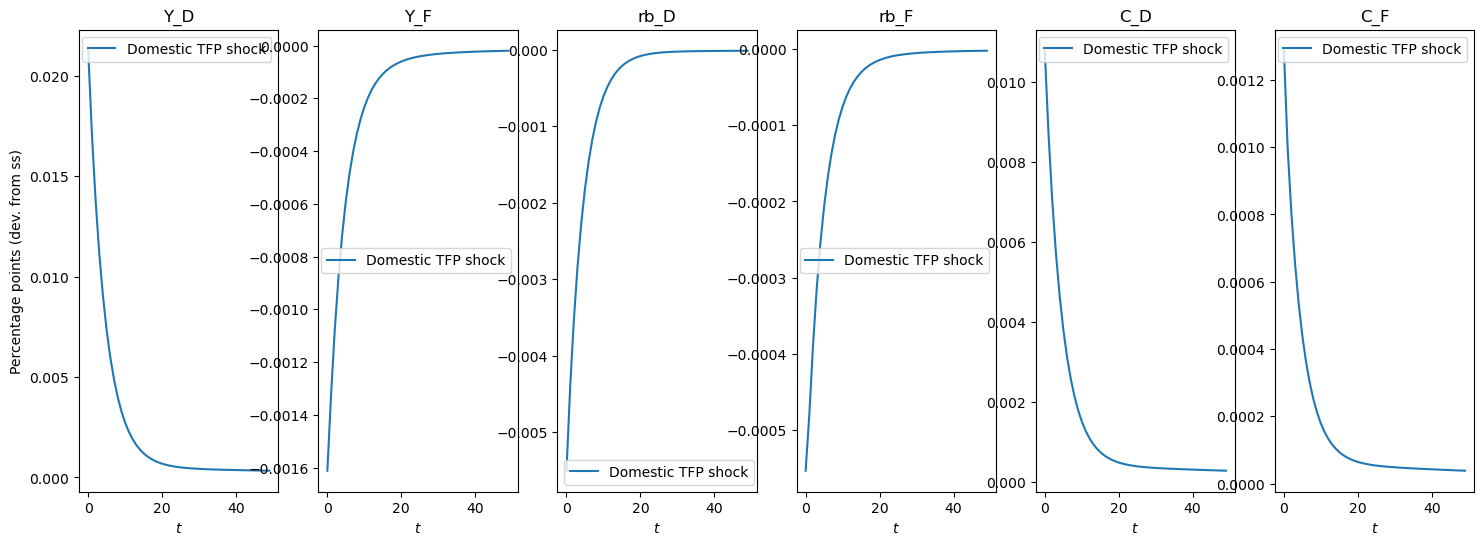

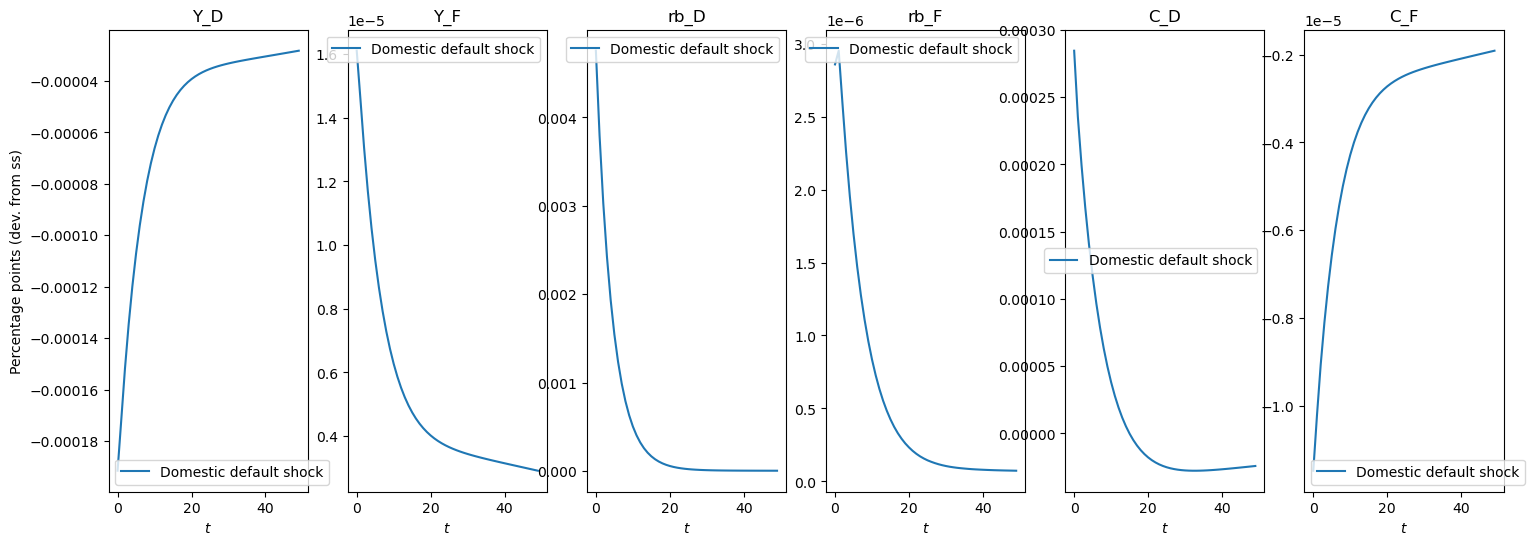

In [ ]:
real = ['Z_D', 'shock_def_D', 'def_rate_D', 'Y_D', 'C_D', 'I_D', 'K_D', 'Q_D', 'N_D', 'w_D', 'iota_D', 'mpk_D', 'cap_profit_D']

financial = [
    'theta_D', 'n_inter_D', 'rn_D', 'nu_D', 'eta_D',
    'rdep_D', 'rb_D', 'rb_actual_D',
    'b_gov_D', 'DEP_D', 'D_supply_D'
]

gov = ['def_rate_D', 'shock_def_D', 'b_gov_D', 'rb_D', 'rb_actual_D', 'TAX_D', 'lamb_D', 'G_D']

residuals = [
    'goods_mkt_D', 'deposit_mkt_D', 'K_res_D', 'n_inter_val_D',
    'div_res_D', 'capital_res_D', 'q_res_D', 'b_gov_res_D',
    'labor_mkt_res_D', 'nu_res_D', 'eta_res_D'
]

# ── IMPORTANT ────────────────────────────────────────────────────────────────
important = ['Y_D', 'Y_F', 'rb_D', 'rb_F', 'C_D', 'C_F']
show_irfs([irfs_Z_D],   important, ['Domestic TFP shock'])
show_irfs([irfs_def_D], important, ['Domestic default shock'])



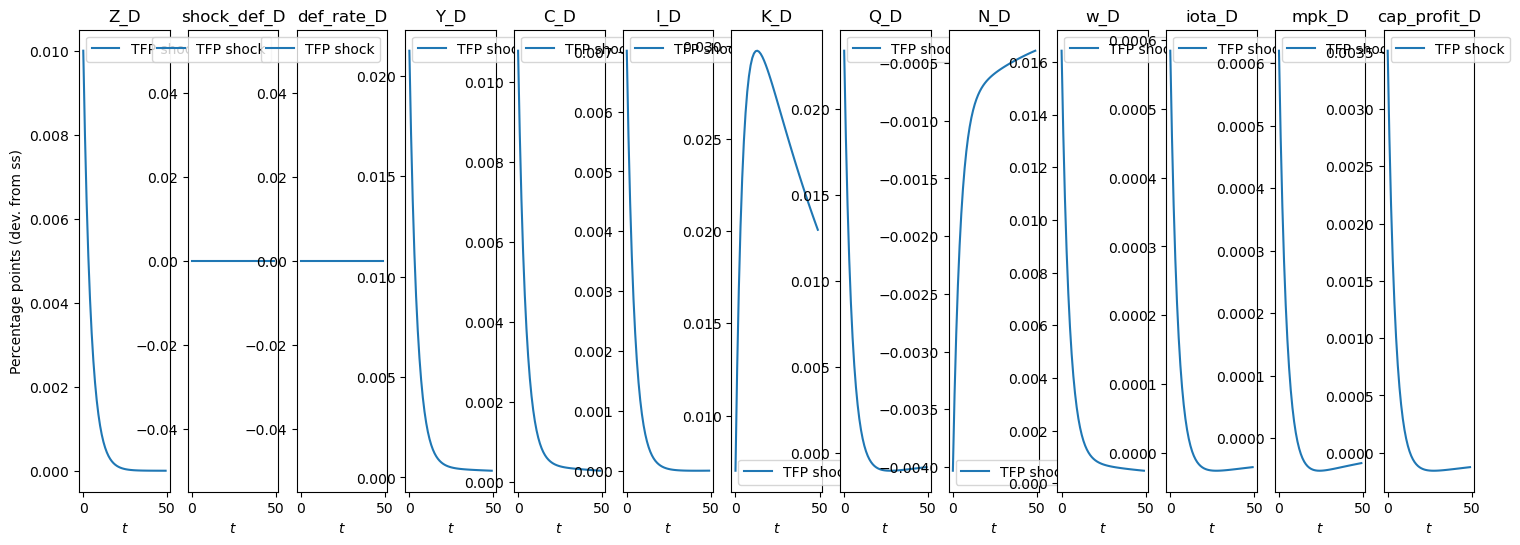

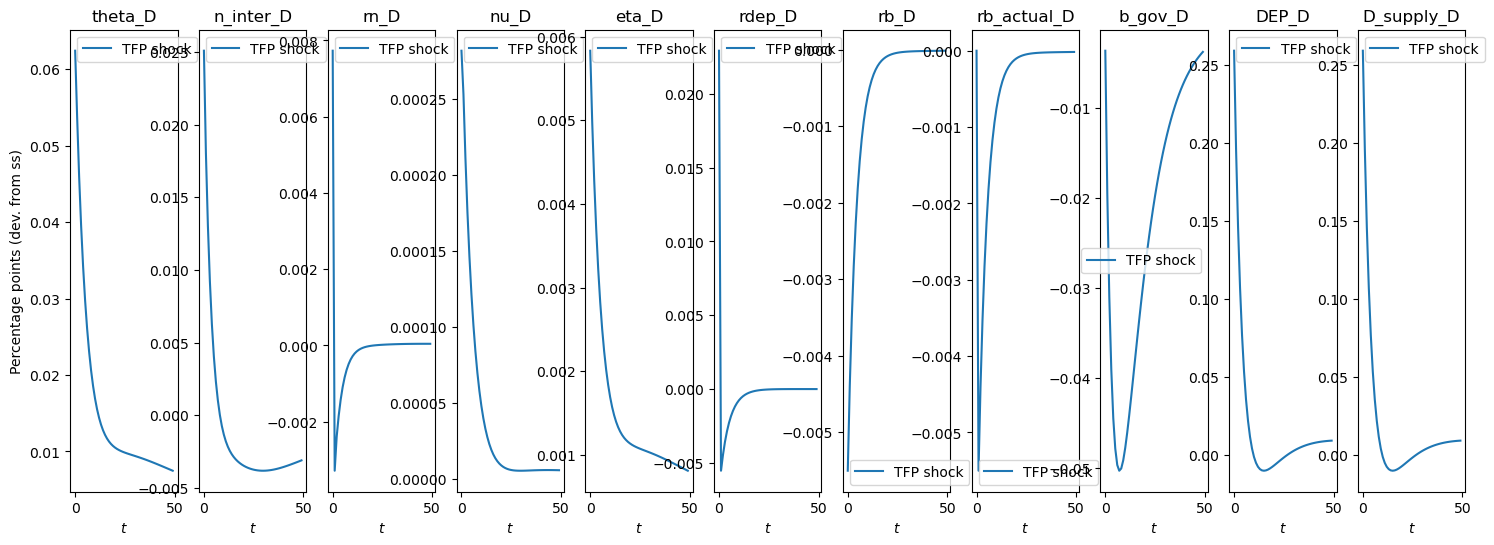

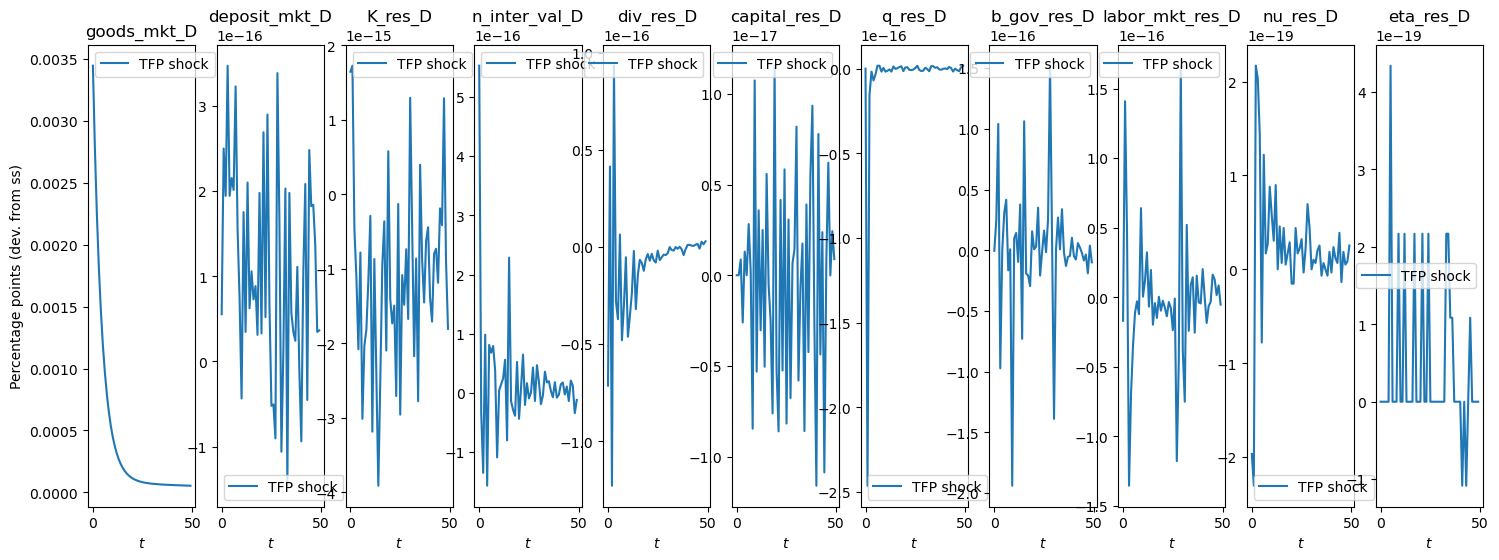

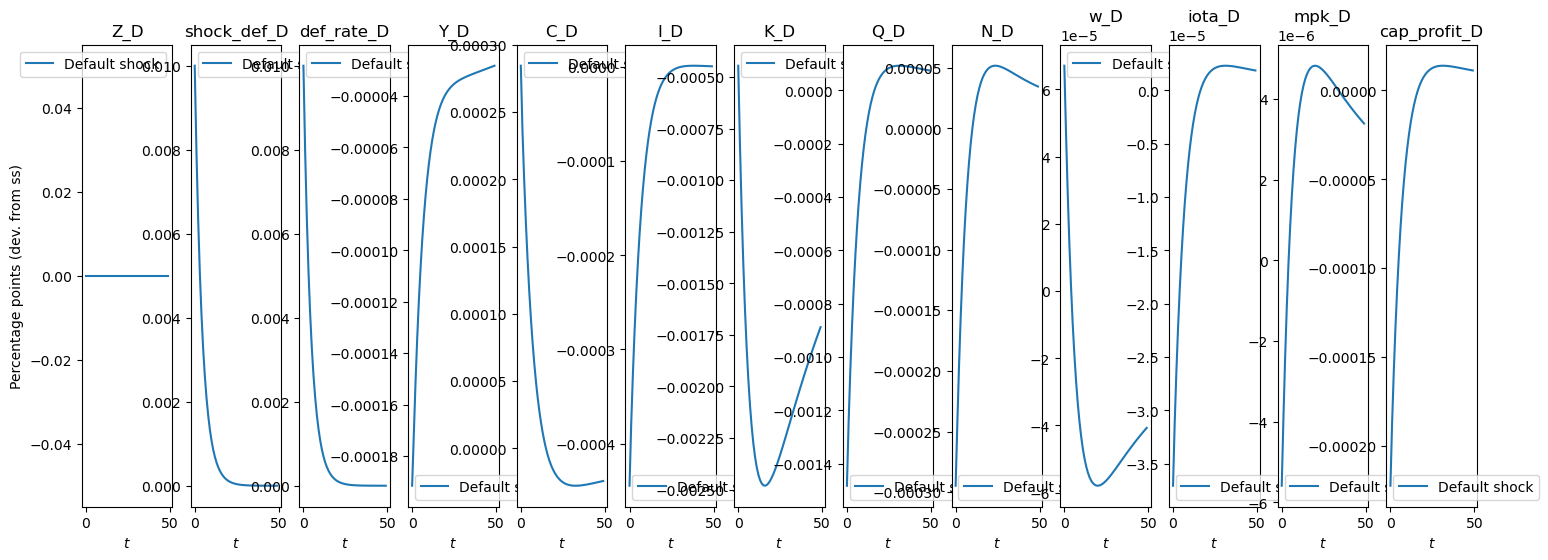

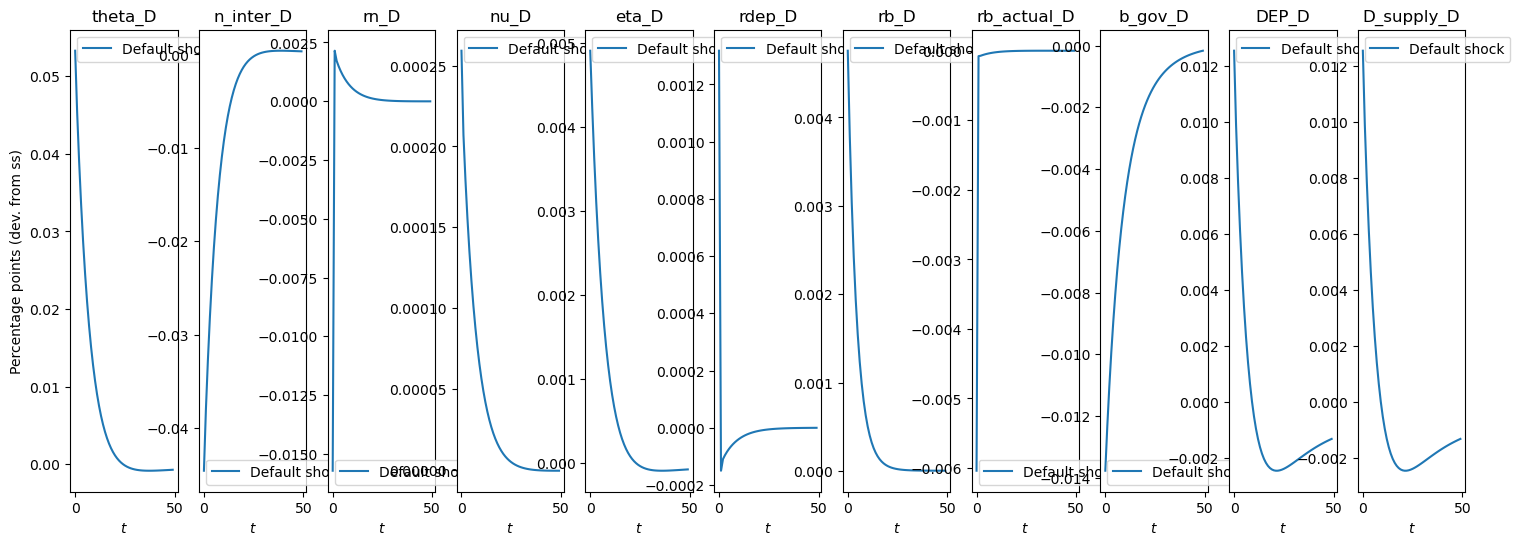

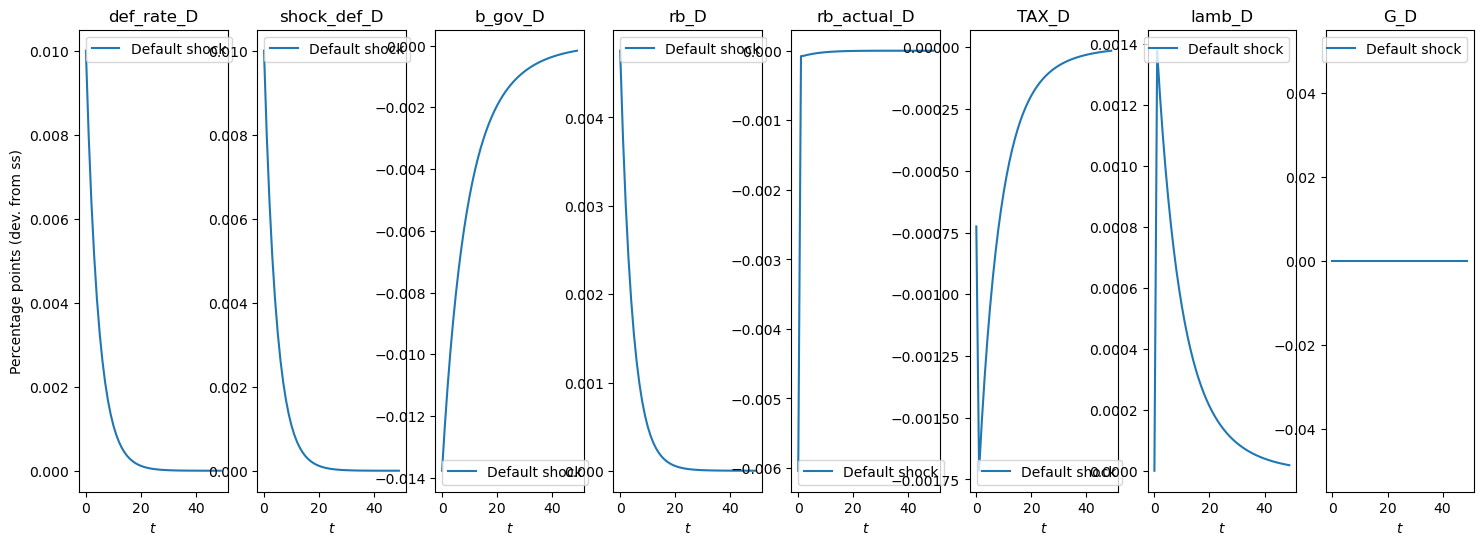

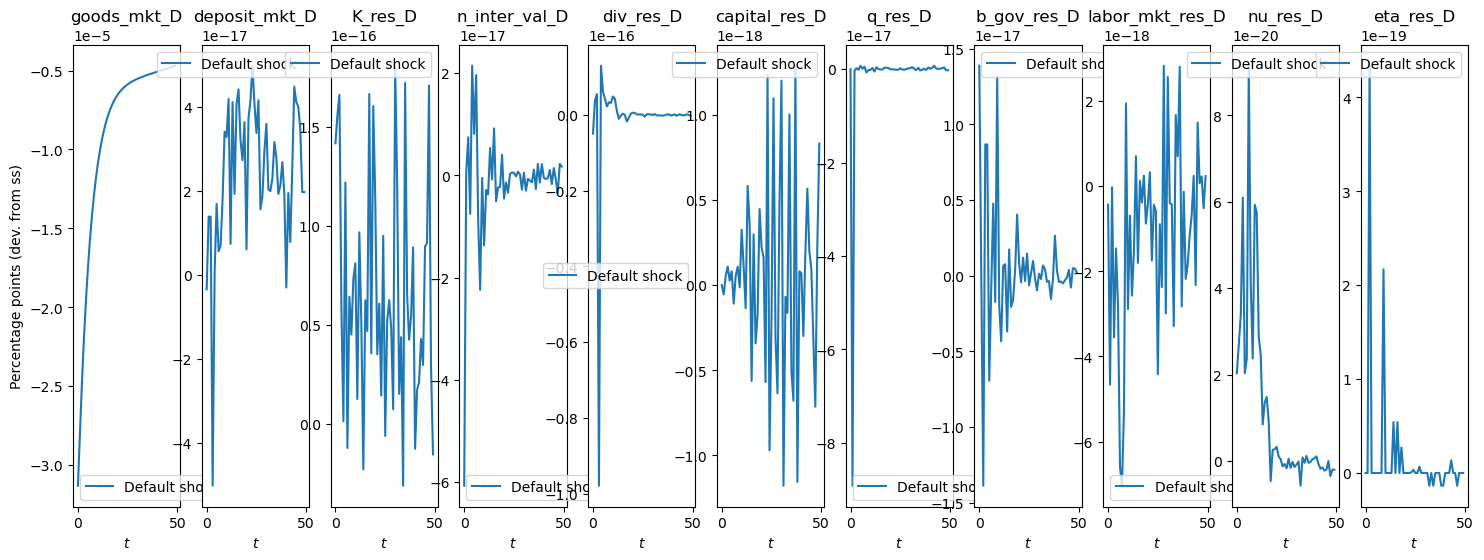

In [12]:
# ── Detailed (muted) ─────────────────────────────────────────────────────────
show_irfs([irfs_Z_D], real, ['TFP shock']) 
show_irfs([irfs_Z_D], financial, ['TFP shock'])
show_irfs([irfs_Z_D], residuals, ['TFP shock'])

show_irfs([irfs_def_D], real, ['Default shock'])
show_irfs([irfs_def_D], financial, ['Default shock']) 
show_irfs([irfs_def_D], gov, ['Default shock'])
show_irfs([irfs_def_D], residuals, ['Default shock'])